In [1]:
import pandas as pd
import time
import json
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import seaborn as sns
import scipy
import pickle as pkl
from collections import OrderedDict

In [2]:
# sick_participants = participant_nums[0]
# healthy_participants = participant_nums[1]

with open('v1_participant_nums.pkl', 'rb') as f:
    v1_participant_nums = pkl.load(f)
    
with open('v2_participant_nums.pkl', 'rb') as f:
    v2_participant_nums = pkl.load(f)
    
with open('v3_participant_nums.pkl', 'rb') as f:
    v3_participant_nums = pkl.load(f)
    
with open('v1_participant_nums_to_symptoms.pkl', 'rb') as f:
    v1_participant_nums_to_symptoms = pkl.load(f)
    
with open('v2_participant_nums_to_symptoms.pkl', 'rb') as f:
    v2_participant_nums_to_symptoms = pkl.load(f)
    
with open('v3_participant_nums_to_symptoms.pkl', 'rb') as f:
    v3_participant_nums_to_symptoms = pkl.load(f)

In [3]:
with open('grouped_participant_nums.pkl', 'rb') as f:
    grouped_participant_nums_readin = pkl.load(f)
    
age1855 = grouped_participant_nums_readin[0]
age55up = grouped_participant_nums_readin[1]
male = grouped_participant_nums_readin[2]
female = grouped_participant_nums_readin[3]
no_umc = grouped_participant_nums_readin[4]
yes_umc = grouped_participant_nums_readin[5]

In [4]:

symp_titles = {'healthy':'No\n Reaction',
               'chest_pain': 'Chest\n Pain',
               'dyspnea':'Dyspnea',
               'heat over 38.9':'Fever\n >38.9',
               'confusion':'Confusion',
               'chills':'Chills',
               'abdominal_pain':'Muscle\n Pain',
               'feel_heat':'Fever\n <=38.9',
               'heat over 37.5':'Fever\n <=38.9',
               'back_or_neck_pain':'Muscle\n Pain',
               'cold':'Cold',
               'muscles_pain':'Muscle\n Pain',
               'weakness':'Fatigue',
               'headache':'Headache',
               'dizziness':'Dizziness',
               'vomiting':'Vomiting',
               'sore_throat':'Sore\n Throat',
               'diarrhea':'Diarrhea',
               'cough':'Cough',
               'hand_muscles_pain':'No\n Reaction',
               'leg_pain':'Muscle\n Pain',
               'ear_pain':'Muscle\n Pain',
               'taste_smell':'Loss of\nTaste/Smell',
               'lymph':'Lymph',
               'fast_heartbeat':'Fast\nHeartbeat',
               'hypertension':'Hypertension',
               'other':'Other',
              '' : 'Skipped Questionnaire'}

labels_old_ordering = ['No\n Reaction',
          'Chest\n Pain',
          'Dyspnea',
          'Fever\n >38.9',
          'Confusion',
          'Chills',
 'Fatigue',
 'Headache',
 'Muscle\n Pain',
 'Fever\n <=38.9',
 'Vomiting',
 'Sore\n Throat',
 'Loss of\nTaste/Smell',
 'Cough',
 'Lymph',
 'Cold',
 'Diarrhea',
 'Fast\nHeartbeat',
]

labels = ['No\n Reaction',
          'Chills',
          'Dyspnea',
          'Confusion',
          'Fever\n >38.9',
          'Chest\n Pain',
 'Fatigue',
 'Headache',
 'Muscle\n Pain',
 'Fever\n <=38.9',
 'Vomiting',
 'Sore\n Throat',
 'Cough',
 'Cold',
 'Diarrhea',
 'Lymph',
 'Fast\nHeartbeat',
 'Loss of\nTaste/Smell',
]

panel_a_labels = [
    'No\n Reaction',
    'Mild\n Reaction',
    'Severe\n Reaction'
]

severe_labels = [
          'Chills',
          'Dyspnea',
          'Confusion',
          'Fever\n >38.9',
          'Chest\n Pain']

mild_labels = [
 'Fatigue',
 'Headache',
 'Muscle\n Pain',
 'Fever\n <=38.9',
 'Vomiting',
 'Sore\n Throat',
 'Cough',
 'Cold',
 'Diarrhea',
 'Lymph',
 'Fast\nHeartbeat',
 'Loss of\nTaste/Smell']

In [5]:
# Ordering:
# [0] = age1855
# [1] = age55up
# [2] = male
# [3] = female
# [4] = no_umc
# [5] = yes_umc

def generate_symptom_dicts_for_subgroups(participant_nums_to_symptoms):
    symptoms_dicts = list()

    for i in range(6):
        symptoms_dicts.append(OrderedDict())

    for k, v in symp_titles.items():
        for i in range(6):
            symptoms_dicts[i][symp_titles[k]] = 0

    for k, v in participant_nums_to_symptoms.items():
        for i in range(6):
            if k in grouped_participant_nums_readin[i]:
                for s in v:
                    symptoms_dicts[i][symp_titles[s]] += 1
    return symptoms_dicts


# Ordering: 
# [0] = Panel A (No, Mild, Severe for Vaccines 1,2,3)
# [1] = Panel B (Severe)
# [2] = Panel C (Mild)
def generate_symptom_dicts(participant_nums_to_symptoms):
    symptoms_dicts = list()

    for i in range(3):
        symptoms_dicts.append(OrderedDict())

    for l in panel_a_labels:
        symptoms_dicts[0][l] = 0
    
    for l in severe_labels:
        symptoms_dicts[1][l] = 0
    
    for l in mild_labels:
        symptoms_dicts[2][l] = 0

    for k, v in participant_nums_to_symptoms.items():
        #for i in range(6):
        #    if k in grouped_participant_nums_readin[i]:
        reaction_severity = "None"
        for s in v:
            symptom = symp_titles[s]
            if symptom in severe_labels:
                if reaction_severity == "None" or reaction_severity == "Mild":
                    reaction_severity = "Severe"
                symptoms_dicts[1][symptom] += 1
            elif symptom in mild_labels:
                if reaction_severity == "None":
                    reaction_severity = "Mild"
                symptoms_dicts[2][symptom] += 1 
            
        
        if reaction_severity == "Severe":
            symptoms_dicts[0]['Severe\n Reaction'] +=1
        elif reaction_severity == "Mild":
            symptoms_dicts[0]['Mild\n Reaction'] +=1
        else:
            symptoms_dicts[0]['No\n Reaction'] +=1  
            
            
        
    return symptoms_dicts

In [6]:
# assert that there are no extra participants whom we have symptoms for
# compared to the participants in our sick/healthy lists
#for k, v in v1_participant_nums_to_symptoms.items():
#    if k not in v1_participant_nums[0] and k not in v1_participant_nums[1]:
#        print(k)

v1_symptoms_dicts = generate_symptom_dicts(v1_participant_nums_to_symptoms)
v2_symptoms_dicts = generate_symptom_dicts(v2_participant_nums_to_symptoms)
v3_symptoms_dicts = generate_symptom_dicts(v3_participant_nums_to_symptoms)

In [7]:
v1_n = len(v1_participant_nums_to_symptoms.keys())
v2_n = len(v2_participant_nums_to_symptoms.keys())
v3_n = len(v3_participant_nums_to_symptoms.keys())

In [8]:
print("Number of participants analyzed after first vaccination: %d" % (v1_n))
print("Number of participants analyzed after second vaccination: %d" % (v2_n))
print("Number of participants analyzed after third vaccination: %d" % (v3_n))

Number of participants analyzed after first vaccination: 204
Number of participants analyzed after second vaccination: 335
Number of participants analyzed after third vaccination: 1179


In [9]:
plt.rcParams.update({'font.size': 22})

In [10]:
def beta(value,n):
    if value == 0:
        return [0,0]
    lower = value-scipy.stats.beta.ppf(0.025, value, n-value + 1, loc=0, scale=1)*n
    upper = scipy.stats.beta.ppf(0.975, value + 1, n-value, loc=0, scale=1)*n-value
    if lower > value:
        lower = value
    return [lower,upper]

In [11]:
v1_symptoms_dicts

[OrderedDict([('No\n Reaction', 169),
              ('Mild\n Reaction', 29),
              ('Severe\n Reaction', 6)]),
 OrderedDict([('Chills', 5),
              ('Dyspnea', 1),
              ('Confusion', 0),
              ('Fever\n >38.9', 0),
              ('Chest\n Pain', 0)]),
 OrderedDict([('Fatigue', 15),
              ('Headache', 11),
              ('Muscle\n Pain', 10),
              ('Fever\n <=38.9', 7),
              ('Vomiting', 2),
              ('Sore\n Throat', 3),
              ('Cough', 5),
              ('Cold', 3),
              ('Diarrhea', 3),
              ('Lymph', 0),
              ('Fast\nHeartbeat', 0),
              ('Loss of\nTaste/Smell', 0)])]

In [12]:
v2_symptoms_dicts

[OrderedDict([('No\n Reaction', 189),
              ('Mild\n Reaction', 94),
              ('Severe\n Reaction', 52)]),
 OrderedDict([('Chills', 44),
              ('Dyspnea', 6),
              ('Confusion', 5),
              ('Fever\n >38.9', 1),
              ('Chest\n Pain', 0)]),
 OrderedDict([('Fatigue', 101),
              ('Headache', 83),
              ('Muscle\n Pain', 80),
              ('Fever\n <=38.9', 54),
              ('Vomiting', 18),
              ('Sore\n Throat', 13),
              ('Cough', 9),
              ('Cold', 12),
              ('Diarrhea', 5),
              ('Lymph', 3),
              ('Fast\nHeartbeat', 2),
              ('Loss of\nTaste/Smell', 0)])]

In [13]:
v3_symptoms_dicts

[OrderedDict([('No\n Reaction', 688),
              ('Mild\n Reaction', 371),
              ('Severe\n Reaction', 120)]),
 OrderedDict([('Chills', 107),
              ('Dyspnea', 13),
              ('Confusion', 10),
              ('Fever\n >38.9', 1),
              ('Chest\n Pain', 1)]),
 OrderedDict([('Fatigue', 301),
              ('Headache', 222),
              ('Muscle\n Pain', 270),
              ('Fever\n <=38.9', 156),
              ('Vomiting', 62),
              ('Sore\n Throat', 34),
              ('Cough', 26),
              ('Cold', 35),
              ('Diarrhea', 32),
              ('Lymph', 29),
              ('Fast\nHeartbeat', 6),
              ('Loss of\nTaste/Smell', 2)])]

In [14]:
list_of_labels = [panel_a_labels, severe_labels, mild_labels]

In [15]:
vaccine_colors = [sns.color_palette('tab10')[4], # first vaccination
                 sns.color_palette('tab10')[2], # second vaccination
                 sns.color_palette('tab10')[3]] # third vaccination

severity_colors = [sns.color_palette('tab10')[7], # no reaction
                 sns.color_palette('tab10')[1], # mild reaction
                 sns.color_palette('tab10')[9]] # severe reaction

In [16]:
titles = ["All Symptoms", "Severe Symptoms", "Mild Symptoms"]

def plot_symptoms_no_subgroup():
    fig = plt.figure(figsize=(25, 15))
    rows = 2
    columns = 2
    grid = plt.GridSpec(rows, columns, wspace = .25, hspace = .25)

    for i in range(3):
        letter = chr(ord('A') + i)
        
        if i==0:
            ax=plt.subplot(grid[0,0])
        if i==1:
            ax=plt.subplot(grid[0,1])
        if i==2:
            ax=plt.subplot(grid[1,:])
        
        labels = list_of_labels[i]
        
        v2_g1_means = [v2_symptoms_dicts[i][j] / v2_n * 100 for j in labels]
        v3_g1_means = [v3_symptoms_dicts[i][j] / v3_n * 100 for j in labels]

        v2_g1_errs = np.array([beta(v2_symptoms_dicts[i][j], v2_n) for j in labels]).T / v2_n * 100
        v3_g1_errs = np.array([beta(v3_symptoms_dicts[i][j], v3_n) for j in labels]).T / v3_n * 100

        x = np.arange(len(labels))  # the label locations
        width = 1

        if i==0:
            plt.bar(x, np.array(v3_g1_means), 0.6, yerr=v3_g1_errs, color=severity_colors)  
        if i==1:
            plt.bar(x, np.array(v3_g1_means), 0.6, yerr=v3_g1_errs, color=severity_colors[2]) 
        if i==2:
            plt.bar(x, np.array(v3_g1_means), 0.6, yerr=v3_g1_errs, color=severity_colors[1]) 

        ax.set_ylabel('Percentage of Participants')
        ax.set_title(titles[i])
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        
        pos = ax.get_position()
        ax.set_yticks(range(0,105,10))
        ax.text(x=-0.05, y=1.1, s=letter, fontweight="bold", size=36, transform=plt.gca().transAxes)
        
        ax.set_xlim(-0.5, len(labels)-0.5)

    plt.suptitle("Questionnaire-Reported Reactions after Third Vaccination")
    plt.show()
    
    fig = plt.figure(figsize=(25, 15))
    rows = 2
    columns = 2
    grid = plt.GridSpec(rows, columns, wspace = .25, hspace = .25)

    for i in range(3):
        letter = chr(ord('A') + i)
        
        if i==0:
            ax=plt.subplot(grid[0,0])
        if i==1:
            ax=plt.subplot(grid[0,1])
        if i==2:
            ax=plt.subplot(grid[1,:])
        
        labels = list_of_labels[i]
        
        v2_g1_means = [v2_symptoms_dicts[i][j] / v2_n * 100 for j in labels]
        v3_g1_means = [v3_symptoms_dicts[i][j] / v3_n * 100 for j in labels]

        v2_g1_errs = np.array([beta(v2_symptoms_dicts[i][j], v2_n) for j in labels]).T / v2_n * 100
        v3_g1_errs = np.array([beta(v3_symptoms_dicts[i][j], v3_n) for j in labels]).T / v3_n * 100

        x = np.arange(len(labels))  # the label locations
        width = 1

        if i==0:
            plt.bar(x, np.array(v2_g1_means), 0.6, yerr=v2_g1_errs, color=severity_colors) 
        if i==1:
            plt.bar(x, np.array(v2_g1_means), 0.6, yerr=v2_g1_errs, color=severity_colors[2])
        if i==2:
            plt.bar(x, np.array(v2_g1_means), 0.6, yerr=v2_g1_errs, color=severity_colors[1])

        ax.set_ylabel('Percentage of Participants')
        ax.set_title(titles[i])
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        
        pos = ax.get_position()
        ax.set_yticks(range(0,105,10))
        ax.text(x=-0.05, y=1.1, s=letter, fontweight="bold", size=36, transform=plt.gca().transAxes)
        
        ax.set_xlim(-0.5, len(labels)-0.5)

    plt.suptitle("Questionnaire-Reported Reactions after Second Vaccination")
    plt.show()

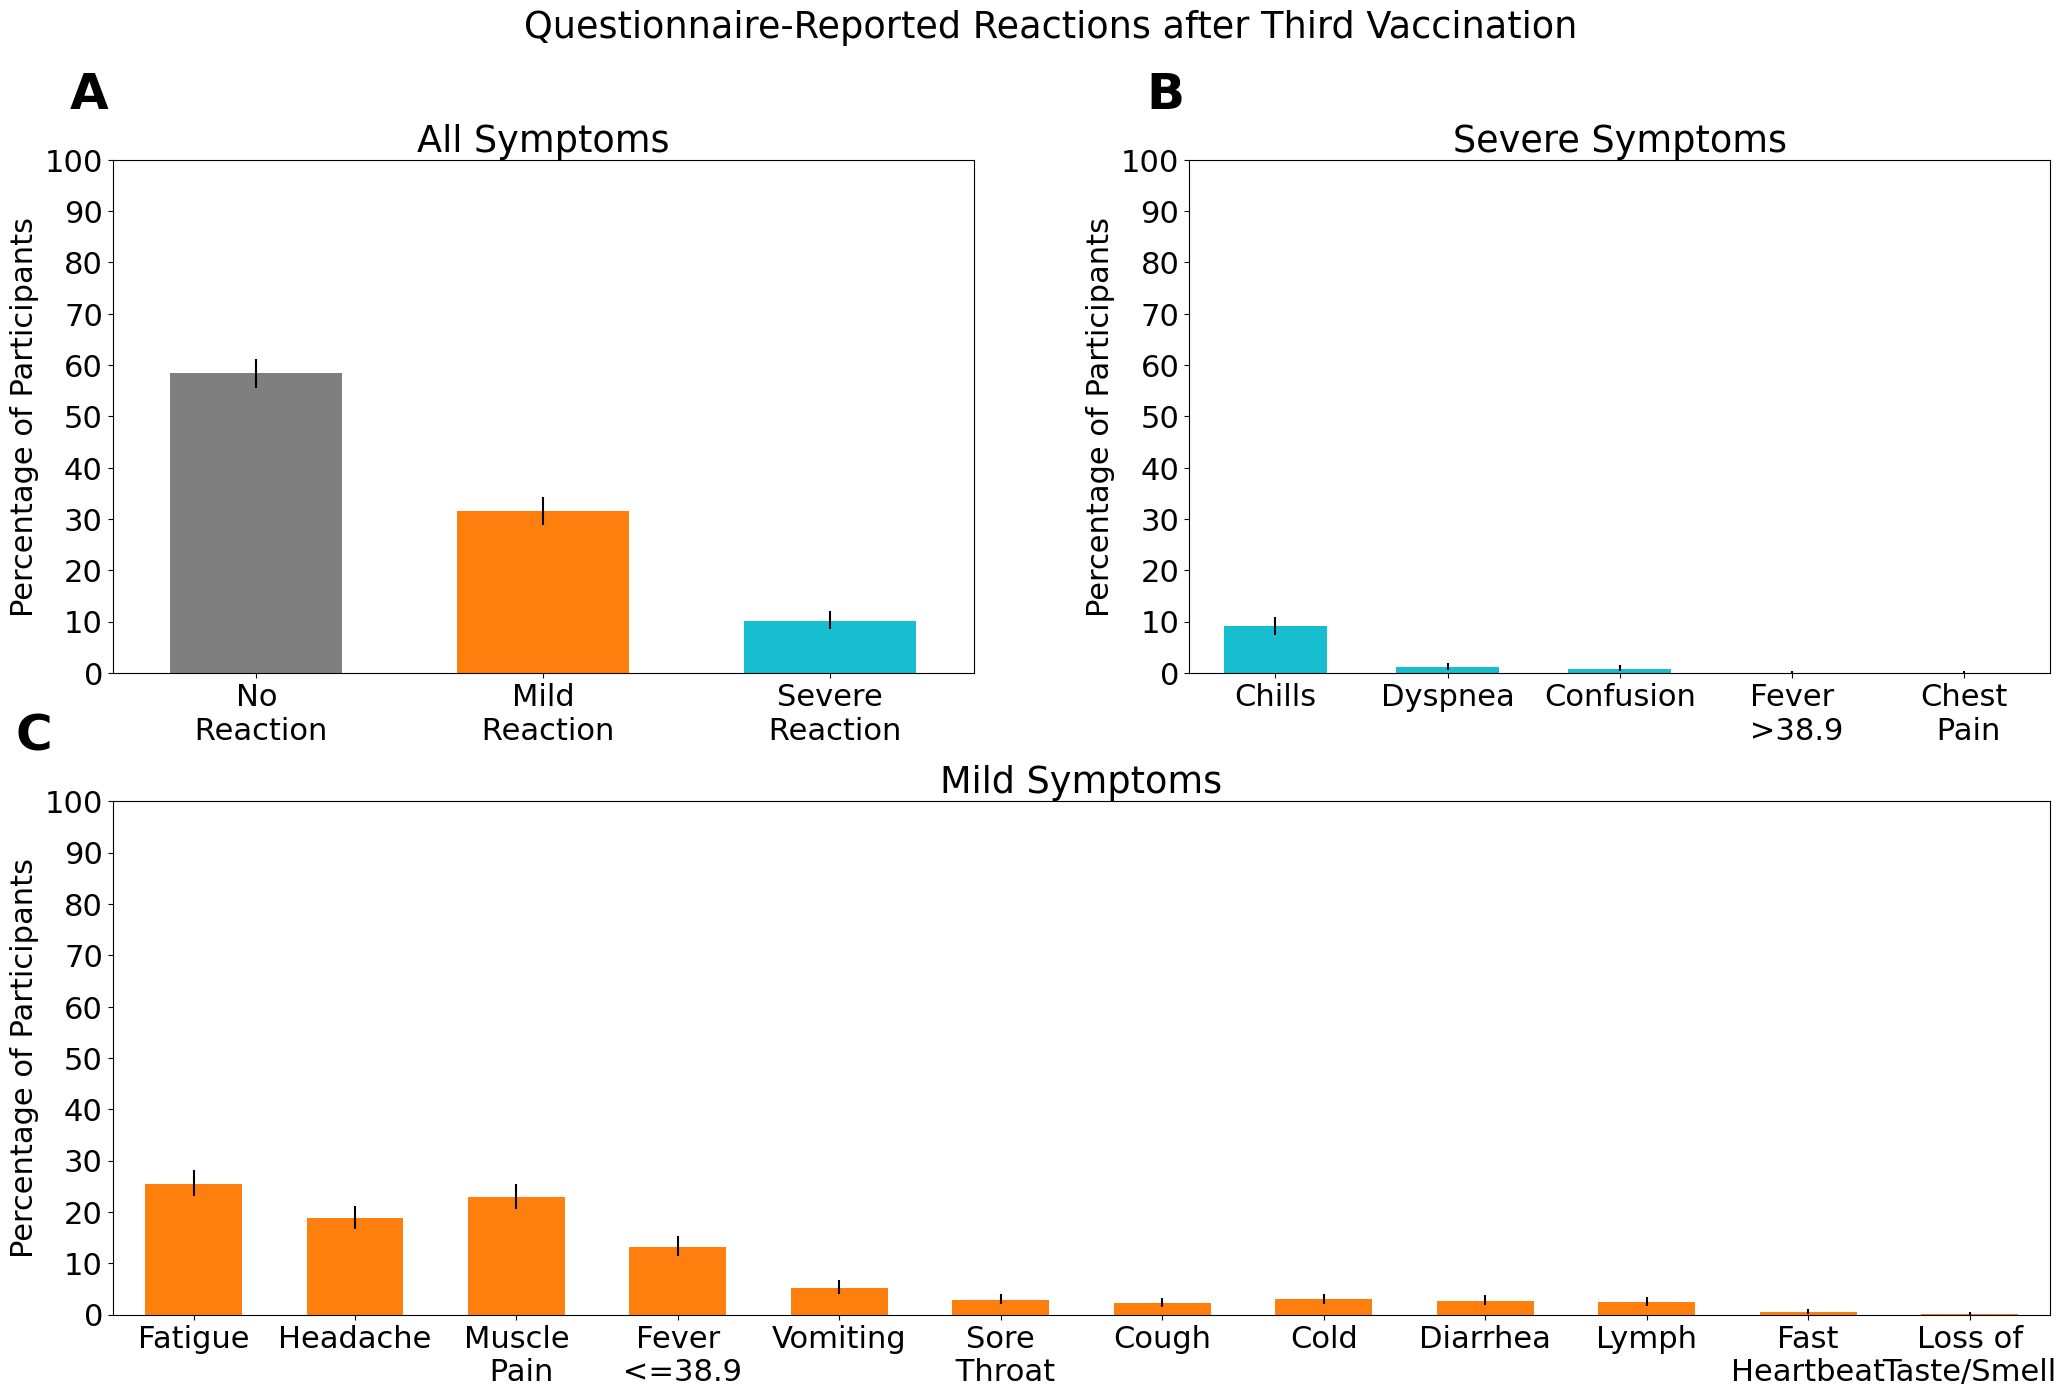

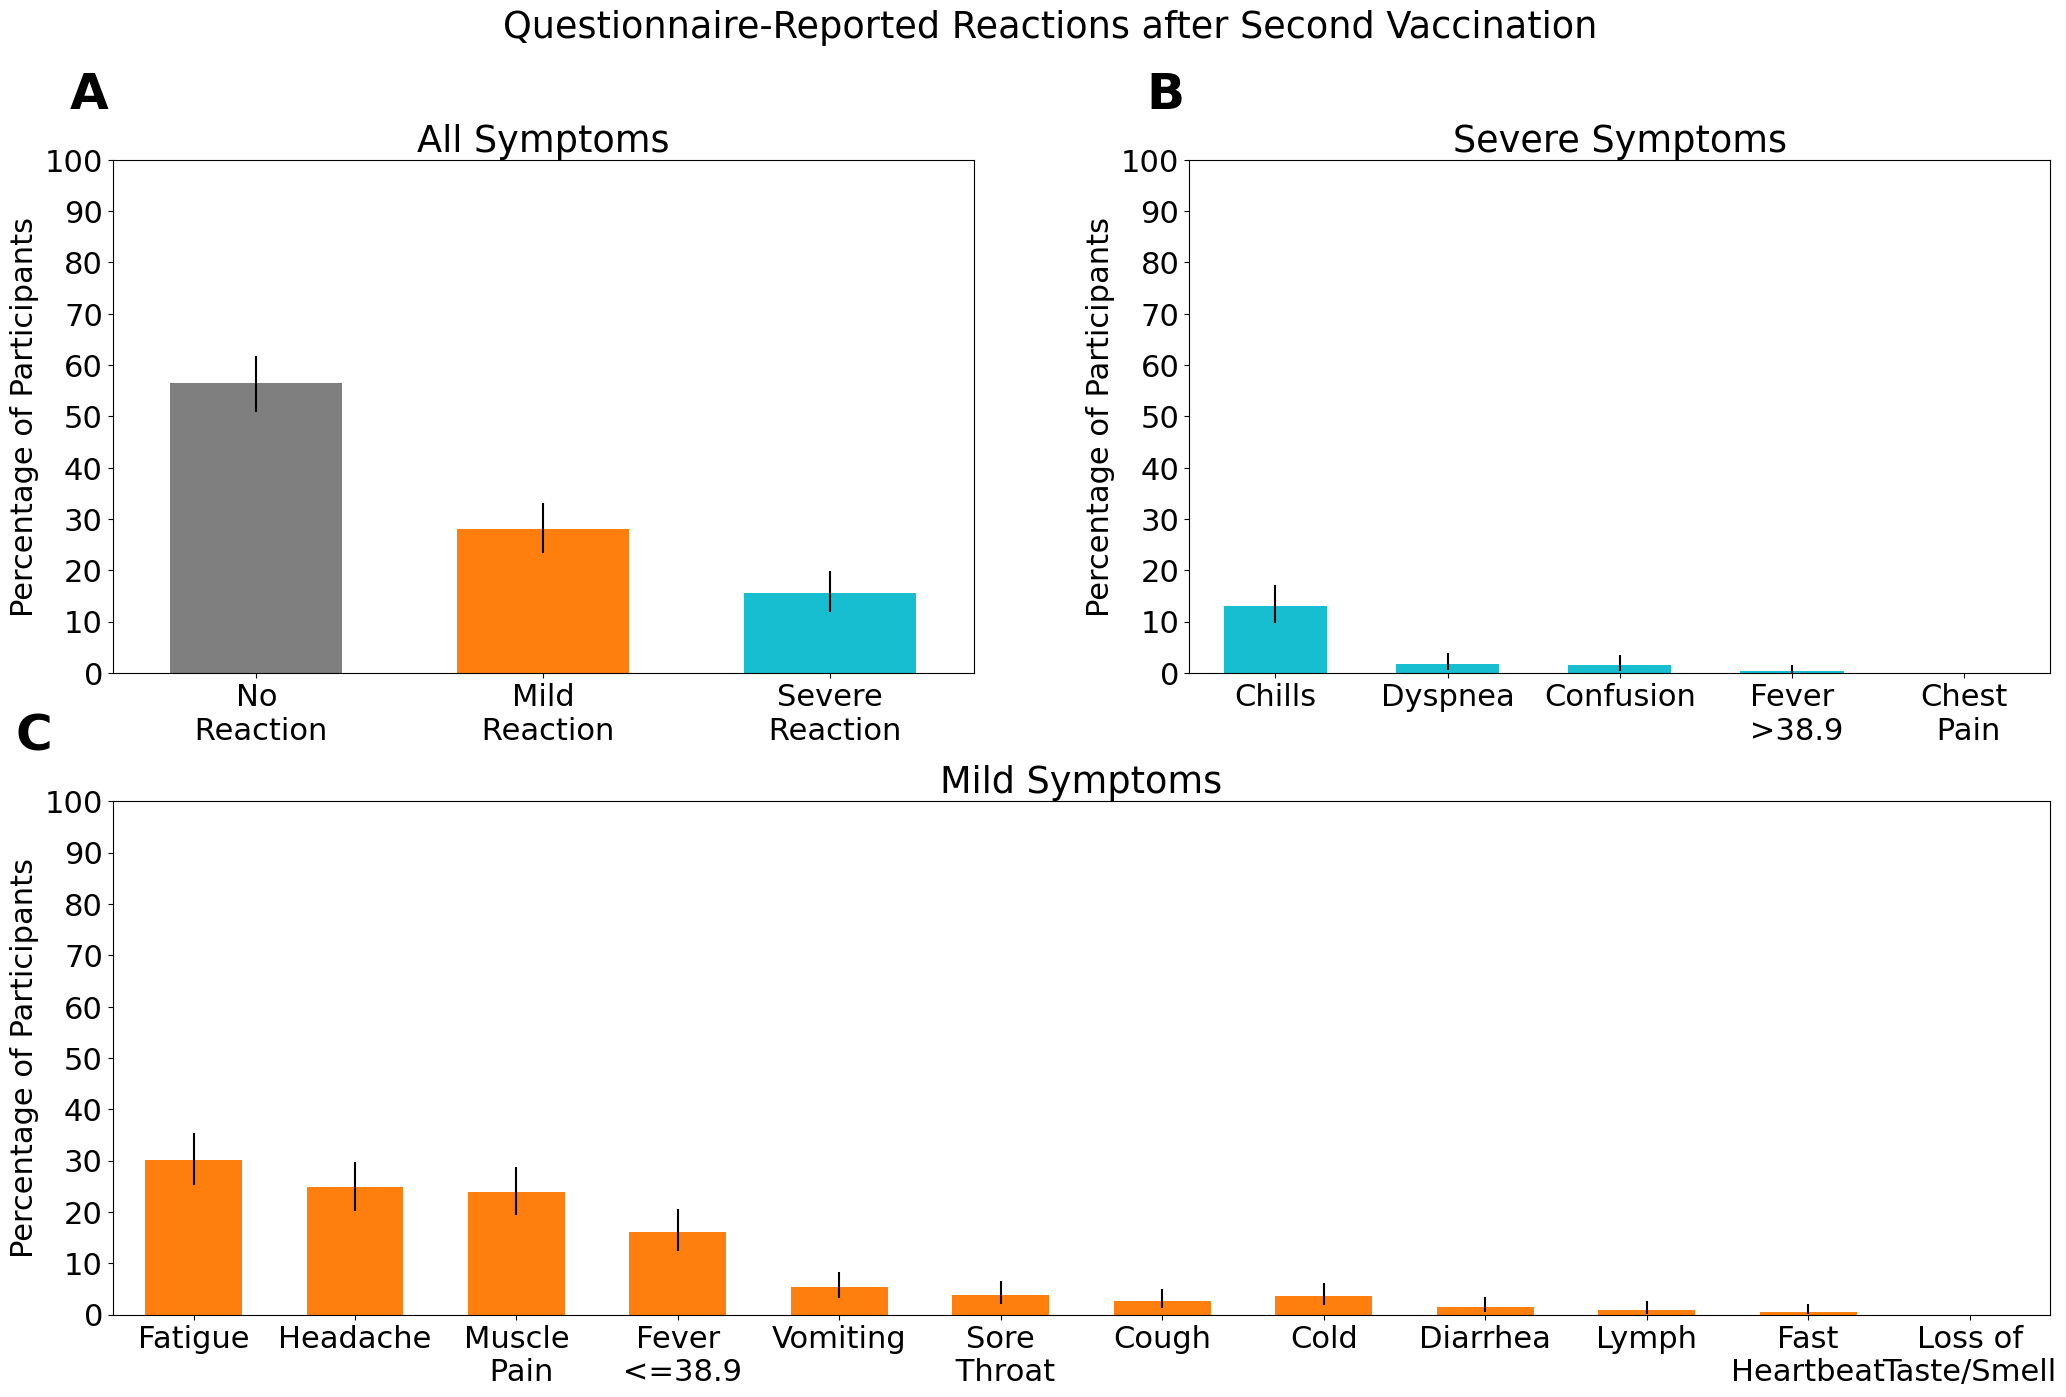

In [17]:
plot_symptoms_no_subgroup()